In [ ]:
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [ ]:
df = pd.read_excel('/content/Dataset for Data Analytics.xlsx')

In [ ]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
df.shape

(1200, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [ ]:
df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


In [ ]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


In [ ]:
df['CouponCode'].value_counts()

,count
CouponCode,
FREESHIP,313
WINTER15,292
SAVE10,286


In [ ]:
threshold = df['TotalPrice'].quantile(0.95)

df['Fraud'] = (df['TotalPrice'] > threshold).astype(int)

print(df['Fraud'].value_counts())

Fraud
0    1140
1      60
Name: count, dtype: int64


In [ ]:
df['OrderStatus'].unique()

array(['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending'],
      dtype=object)

In [ ]:
df['Fraud'].value_counts()

,count
Fraud,
0,1200


In [ ]:
df['Fraud'].value_counts(normalize=True) * 100

,proportion
Fraud,
0,100.0


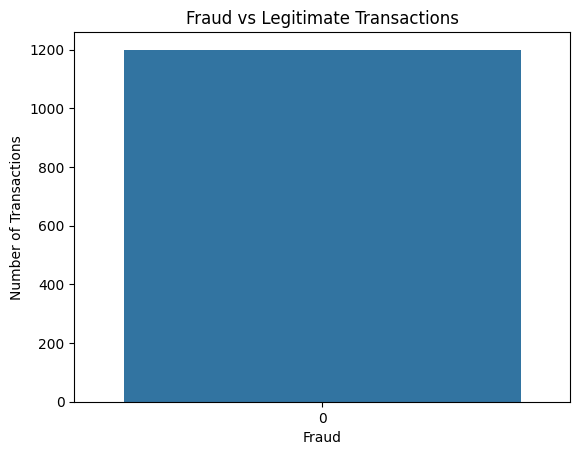

In [ ]:
sns.countplot(x='Fraud', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Fraud')
plt.ylabel('Number of Transactions')
plt.show()

In [ ]:
df['TotalItemsValue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [ ]:
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

In [ ]:
drop_columns = [
    'OrderID',
    'CustomerID',
    'ShippingAddress',
    'TrackingNumber',
    'Date',
    'Fraud'
]

In [ ]:

X = df.drop(columns=drop_columns)
y = df['Fraud']

print(y.value_counts())

Fraud
0    1140
1      60
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(exclude=['object']).columns

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("y_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

y_train:
Fraud
0    912
1     48
Name: count, dtype: int64

y_test:
Fraud
0    228
1     12
Name: count, dtype: int64


In [ ]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [ ]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'TotalItemsValue',
       'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode',
       'ReferralSource'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
lr_precision = precision_score(y_test, lr_pred)
print("Precision:", lr_precision)

Precision: 0.7692307692307693


In [ ]:
lr_recall = recall_score(y_test, lr_pred)
print("Recall:", lr_recall)

Recall: 0.8333333333333334


In [ ]:
lr_f1 = f1_score(y_test, lr_pred)
print("F1 Score:", lr_f1)

F1 Score: 0.8


In [ ]:
lr_auc = roc_auc_score(y_test, lr_prob)
print("ROC-AUC:", lr_auc)

ROC-AUC: 0.9948830409356725


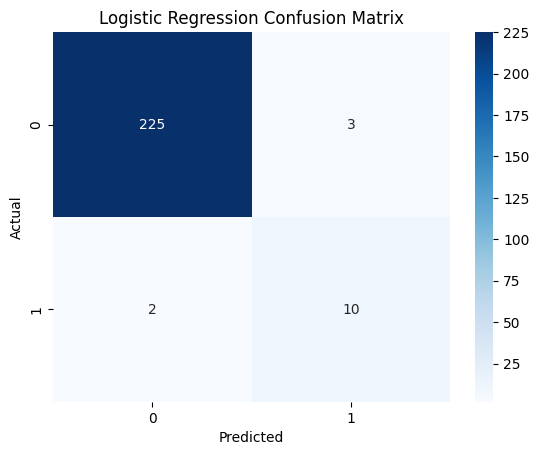

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ))
])

In [ ]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'TotalItemsValue',
       'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode',
       'ReferralSource'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1:", rf_f1)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest Precision: 1.0
Random Forest Recall: 0.9166666666666666
Random Forest F1: 0.9565217391304348
Random Forest ROC-AUC: 1.0


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall],
    'F1 Score': [lr_f1, rf_f1],
    'ROC-AUC': [lr_auc, rf_auc]
})

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.769231,0.833333,0.800000,0.994883
1,Random Forest,1.000000,0.916667,0.956522,1.000000


In [ ]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

In [ ]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'TotalItemsValue',
       'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode',
       'ReferralSource'],
      dtype='object'))])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 20, None],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='roc_auc')

In [ ]:
print(grid_search.best_params_)

{'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [ ]:
print(grid_search.best_score_)

1.0


In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Precision:",
      precision_score(y_test, final_pred))

print("Recall:",
      recall_score(y_test, final_pred))

print("F1 Score:",
      f1_score(y_test, final_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, final_prob))

Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


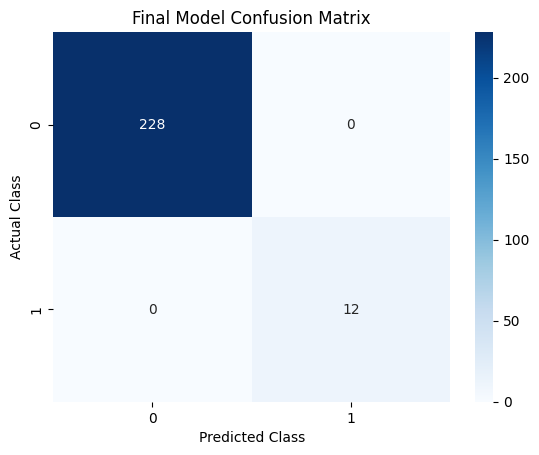

In [ ]:
cm = confusion_matrix(y_test, final_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Final Model Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

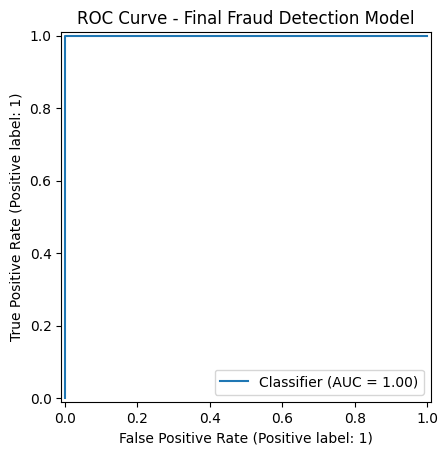

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    final_prob
)

plt.title('ROC Curve - Final Fraud Detection Model')
plt.show()